In [2]:
import pandas as pd
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load scored dataset
df_clean = pd.read_csv('data/processed/nike_bert_scored.csv')
print(f"Loaded {len(df_clean)} tweets")
print(df_clean['clean_text'].head(3))

Loaded 9941 tweets
0                                            ahhh hope
1                                 cool tweet apps razr
2    know family drama lamehey next time hang kim g...
Name: clean_text, dtype: str


In [3]:
# Prepare texts
docs = df_clean['clean_text'].astype(str).tolist()

# Initialize BERTopic with settings optimized for short tweets
vectorizer_model = CountVectorizer(
    ngram_range=(1, 2),
    stop_words="english",
    min_df=5
)

topic_model = BERTopic(
    vectorizer_model=vectorizer_model,
    language="english",
    calculate_probabilities=True,
    verbose=True,
    nr_topics="auto",
    min_topic_size=50
)

print("Training BERTopic on 9,941 tweets...")
print("This will take 3-5 minutes...")
topics, probs = topic_model.fit_transform(docs)

print("\n[OK] BERTopic training complete")
print(f"Number of topics found: {len(topic_model.get_topic_info()) - 1}")

2026-06-01 16:17:50,956 - BERTopic - Embedding - Transforming documents to embeddings.


Training BERTopic on 9,941 tweets...
This will take 3-5 minutes...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/311 [00:00<?, ?it/s]

2026-06-01 16:18:41,356 - BERTopic - Embedding - Completed ✓
2026-06-01 16:18:41,357 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-01 16:19:15,656 - BERTopic - Dimensionality - Completed ✓
2026-06-01 16:19:15,661 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-01 16:19:16,921 - BERTopic - Cluster - Completed ✓
2026-06-01 16:19:16,921 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-06-01 16:19:17,109 - BERTopic - Representation - Completed ✓
2026-06-01 16:19:17,112 - BERTopic - Topic reduction - Reducing number of topics
2026-06-01 16:19:17,127 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-01 16:19:17,303 - BERTopic - Representation - Completed ✓
2026-06-01 16:19:17,306 - BERTopic - Topic reduction - Reduced number of topics from 29 to 29



[OK] BERTopic training complete
Number of topics found: 28


In [4]:
print(topic_model.get_topic_info().to_string())

    Topic  Count                               Name                                                                           Representation                                                                                                                                                                                                    Representative_Docs
0      -1   4796             -1_like_got_love_going                               [like, got, love, going, good, time, dont, day, lol, know]                                                                       [aaah sorry know love really hee hee, fcuuuk bad got stood night rowman need new friend, think going durin thhe week asweel want time may limit]
1       0    563           0_food_eat_dinner_eating                         [food, eat, dinner, eating, coffee, lunch, ice, good, ate, want]                                                                                                            [hooray get throw food fridge, shemallen

In [5]:
# Label the most relevant topics
topic_labels = {
    0: "Food & Dining",
    1: "Sleep & Fatigue", 
    3: "Twitter & Social Media",
    4: "Weather & Outdoor Activity",
    5: "Health & Wellbeing",
    6: "Work & Weekly Routine",
    7: "Music & Entertainment",
    8: "Technology & Smartphones",
    11: "Movies & TV",
    12: "Family & Relationships",
    15: "Education & Study",
    21: "Fashion & Shopping",
}

# Get top 8 topics by size excluding -1 (outliers)
top_topics = topic_model.get_topic_info()
top_topics = top_topics[top_topics['Topic'] != -1].head(8)

print("Top 8 Topics:")
for _, row in top_topics.iterrows():
    topic_num = row['Topic']
    label = topic_labels.get(topic_num, f"Topic {topic_num}")
    words = topic_model.get_topic(topic_num)
    word_list = [w[0] for w in words[:5]]
    print(f"{label} ({row['Count']} tweets): {', '.join(word_list)}")

Top 8 Topics:
Food & Dining (563 tweets): food, eat, dinner, eating, coffee
Sleep & Fatigue (444 tweets): sleep, bed, night, tired, goodnight
Topic 2 (420 tweets): good, thats, lol, know, sure
Twitter & Social Media (347 tweets): twitter, tweet, reply, dont, know
Weather & Outdoor Activity (332 tweets): weather, sun, cold, summer, hot
Health & Wellbeing (314 tweets): sick, feeling, feel, hurt, better
Work & Weekly Routine (314 tweets): work, weekend, monday, week, working
Music & Entertainment (281 tweets): song, listening, music, new, love


In [9]:
df_clean['topic'] = topics
df_clean['topic_label'] = df_clean['topic'].map(topic_labels).fillna('Other')
df_clean.to_csv('data/processed/nike_final_scored.csv', index=False)
print("[OK] Final dataset saved with topic labels")
print(f"\nTopic distribution:")
print(df_clean['topic_label'].value_counts().head(10))

[OK] Final dataset saved with topic labels

Topic distribution:
topic_label
Other                         6260
Food & Dining                  563
Sleep & Fatigue                444
General Conversation           420
Twitter & Social Media         347
Weather & Outdoor Activity     332
Health & Wellbeing             314
Work & Weekly Routine          314
Music & Entertainment          281
Technology & Smartphones       169
Name: count, dtype: int64


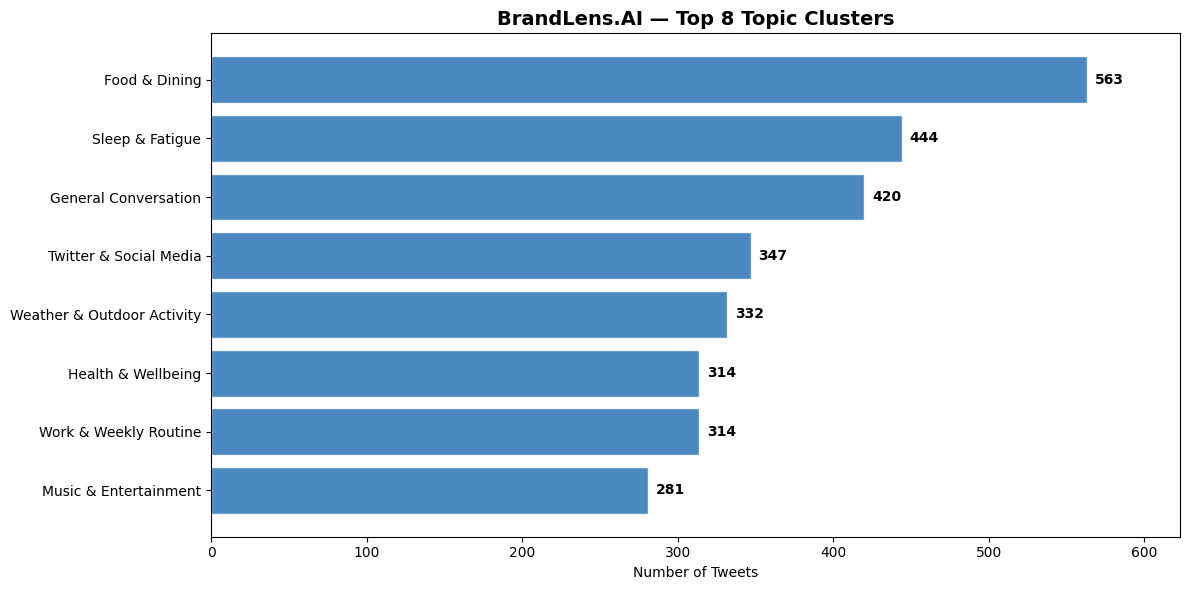

[OK] Updated chart saved


In [8]:
# Add missing label for topic 2
topic_labels[2] = "General Conversation"

# Replot with corrected labels
top8 = topic_model.get_topic_info()[1:9]
labels = [topic_labels.get(t, f"Topic {t}") for t in top8['Topic']]
counts = top8['Count'].values

plt.figure(figsize=(12, 6))
bars = plt.barh(labels, counts,
                color='#2E75B6', edgecolor='white', alpha=0.85)

for bar, val in zip(bars, counts):
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=10, fontweight='bold')

plt.title('BrandLens.AI — Top 8 Topic Clusters',
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Tweets')
plt.xlim(0, max(counts) + 60)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('outputs/topic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("[OK] Updated chart saved")